# Regression

## Regression with One Variable

Regression aims to predict a continuous numerical output based on one or more input variables.

Linear regression is a specific regression technique that assumes the relationship between input $x$ and output $y$ is linear. 

![linear_regression_example](../img/linear_regression_example.png)

To calculate the predicted output using linear regression, we either use:

- $f_{w,b}(x) = wx+b$ for a single feature
- $f_{w,b}​(x)=w_1​x_1​+w_2​x_2​+...+w_n​x_n​+b$ for multiple features

where $w$ and $b$ are parameters.

In our single feature model, any point from the function is numbered. For example, the following point $i$ has coordinates $(x^i, y^i)$.

![linreg-point-annotation](../img/linreg-point-annotation.png)

$y^i$ is the actual value from our dataset. $\hat{y}^i$ is the predicted value from the model.

![linreg-prediction-annotation](../img/linreg-prediction-annotation.png)

Mathematically, $\hat{y}^i = f_{w,b}(x^i)= wx^i+b$. Obviously, our goal is to have a predicted value $\hat{y}$ as close as possible to the actual value $y$. We therefore need to find the best corresponding values for $w$ and $b$.

### Model Representation

We will use a simple data set with only two data points - a house with 1000 square feet(sqft) sold for $300,000 and a house with 2000 square feet sold for $500,000. These two points will constitute our *data or training set*. 

The objective is to fit a linear regression model through these two points, in order to predict the price for other houses.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# x_train is the input variable (size in 1000 square feet)
# y_train is the target (price in 1000s of dollars)
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1. 2.]
y_train = [300. 500.]


In [ ]:
# m is the number of training examples
print(f"x_train.shape: {x_train.shape}")
m = x_train.shape[0]
print(f"Number of training examples is: {m}")

In [ ]:
i = 0 # Change this to 1 to see (x^1, y^1)
x_i = x_train[i]
y_i = y_train[i]
print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")

(x^(0), y^(0)) = (1.0, 300.0)


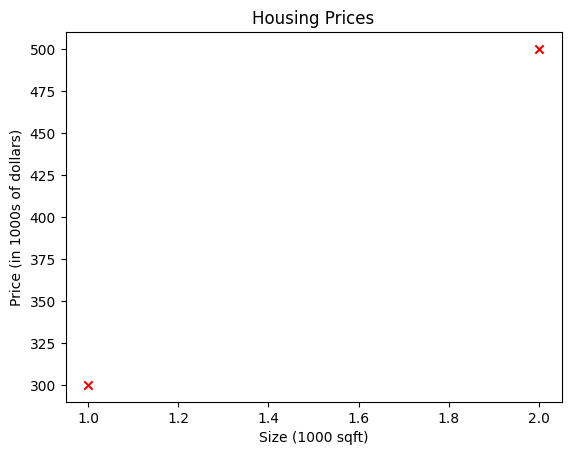

In [12]:
plt.scatter(x_train, y_train, marker='x', c='r')
plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.show()

In [16]:
w = 200
b = 100
print(f"w: {w}")
print(f"b: {b}")

w: 200
b: 100


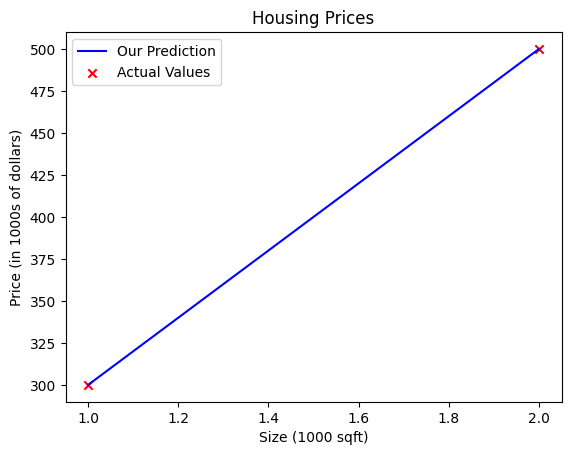

In [17]:
def compute_model_output(x, w, b):
    """
    Computes the prediction of a linear model
    Args:
      x (ndarray (m,)): Data, m examples 
      w,b (scalar)    : model parameters  
    Returns
      f_wb (ndarray (m,)): model prediction
    """
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
        
    return f_wb

tmp_f_wb = compute_model_output(x_train, w, b,)

# Plot our model prediction
plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')
# Plot the data points
plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')

plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()

The above graph shows that $w = 200$ and $b = 100$ result in a perfect line that fits the data. 

Now that we have a model, we can use it to **make a prediction**. Let's predict the price of a house with 1200 sqft. Since the units of $x$ are in 1000's of sqft, $x$ is 1.2.


In [18]:
w = 200                         
b = 100    
x_i = 1.2
cost_1200sqft = w * x_i + b    

print(f"${cost_1200sqft:.0f} thousand dollars")

$340 thousand dollars



### Cost Function

To do that, we use the Cost Function (or Squared Error Cost Function), which takes the prediction $\hat{y}$ and compares it to the target $y$.

$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^m (\hat{y}^i - y^i)^2
$$

where: 

- $\hat{y} - y$ is the error 
- m is the number of training examples
- the factor $\frac{1}{2}$ is included by convention to simplify derivatives during gradient calculations


Notice that by removing the $\frac{1}{2}$, we get the Mean Squared Error (MSE): 

$$
MSE = \frac{1}{m} \sum_{i=1}^m (\hat{y}^i - y^i)^2
$$

The cost function $J$ models the difference between the model's prediction and the actual true value of $y$. In other words, we want to minimize $J(w, b)$.

Shape of the J function: 

![cost-function-bowl](../img/cost-function-bowl.png)

A contour plot is also used to visualize the function in parameter space:

![cost-function-contour](../img/cost-function-contour.png)

Each contour line represents points where the cost function has the same value.

### Gradient Descent

Gradient descent is a widely used algorithm to find the values of $w$ and $b$ that minimize $J(w,b)$. It is also used for training advanced neural network models. Gradient descent can be used to minimize any function (not limited to cost functions).

**How it works**

- Start with any value of $w$ and $b$ (usually $w = 0$ and $b = 0$)
- Keep changing $w$ and $b$ to reduce $J(w,b)$
- Stop when we settle at a local minimum (there may be multiple minimums)

**The Gradient Descent Algorithm**

At each step, we update both parameters simultaneously:

$$
\text{repeat until convergence:} \quad \left\{
\begin{aligned}
w &= w - \alpha \frac{\partial}{\partial w} J(w, b) \\
b &= b - \alpha \frac{\partial}{\partial b} J(w, b)
\end{aligned}
\right.
$$

where $\alpha$ is the **learning rate** (a small positive number that controls the step size).

We must update both $w$ and $b$ at the same time using the **current** values until convergence (i.e. stop when we reach a point where the gradient is approximately zero).

### Intuition

Recall that the derivative of a function at a particular value is the slope of the tangent line to the function’s graph at that point.

Let's take this simple quadratic function as example. 

![gradient-descent-intuition-example](../img/grad-desc-intuition-example.png)

Since $\alpha$ is a positive number, updating $w$ each time will give us two cases: 

- If the slope $\frac{\partial}{\partial w} J(w, b) $ is positive, the function is increasing → $w$ decreases, moves toward left
- If the slope is negative, the function is decreasing → $w$ increases, moves toward right.

![gradient-descent-formula-intuition](../img/grad-desc-intuition-formula.png)


**On the learning rate**

- If $\alpha$ is too small, it may take a long time until reaching convergence.
- If $\alpha$ is too large, it may overshoot the minimum (never reaching it). 

![bad-learning-rates](../img/bad-learning-rates.png)


Notice that if the current value is already a local minimum, the derivative is equal to 0. Hence updating $w$ still gives us $w$. 

![already-at-a-local-minimum](../img/already-local-minimum.png)

**For Linear Regression**

The partial derivatives of the cost function are:

$$
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=1}^m (f_{w,b}(x^i) - y^i) \cdot x^i
$$

$$
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=1}^m (f_{w,b}(x^i) - y^i)
$$

**Proof** 

For $w$:

\begin{align*}
\frac{\partial}{\partial w} J(w, b)
&= \frac{\partial}{\partial w} \left( \frac{1}{2m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \right) \\
&= \frac{\partial}{\partial w} \left( \frac{1}{2m} \sum_{i=1}^{m} (w x^{(i)} + b - y^{(i)})^2 \right) \\
&= \frac{1}{2m} \sum_{i=1}^{m} (w x^{(i)} + b - y^{(i)}) \, 2x^{(i)} \\
&= \frac{1}{m} \sum_{i=1}^{m} (w x^{(i)} + b - y^{(i)}) \, x^{(i)} \\
&= \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^i) - y^i)x^i
\end{align*}

For $b$:
\begin{align*}
\frac{\partial}{\partial b}J(w,b) 
&= \frac{\partial}{\partial b} \left( \frac{1}{2m} \sum_{i=1}^{m}(f_{w,b}(x^{(i)})-y^{(i)})^2 \right) \\
&= \frac{\partial}{\partial b} \left( \frac{1}{2m} \sum_{i=1}^{m} (wx^{(i)}+b-y^{(i)})^2 \right) \\
&= \frac{1}{2m}\sum_{i=1}^{m}(wx^{(i)}+b-y^{(i)})\cdot 2 \\
&= \frac{1}{m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)})-y^{(i)}\right)
\end{align*}

Substituting into the gradient descent algorithm gives us: 

$$
\text{repeat until convergence:} \quad \left\{
\begin{aligned}
w &= w - \alpha \frac{1}{m} \sum_{i=1}^m (f_{w,b}(x^i) - y^i) \cdot x^i \\
b &= b - \alpha \frac{1}{m} \sum_{i=1}^m (f_{w,b}(x^i) - y^i)
\end{aligned}
\right.
$$


## Regression with Multiple Input Variables

One-feature regression consists in predicting a value $y$ using a feature $x$. Multiple-feature regression instead uses multiple features $x_1$, $x_2$, $x_3$, ..., $x_n$ to predict $y$.

For example, instead of predicting the price of a house using its size, we might add its number of bedrooms, number of floors, etc...

The model function is:

$$
f_{w,b}(x) = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b
$$

In vector notation, this corresponds to:  

$$
f_{\vec{w}, b}(\vec{x}) = \vec{w} \cdot \vec{x} + b
$$

where  
- $\vec{x} = [x_1, x_2, \ldots, x_n]$  
- $\vec{w} = [w_1, w_2, \ldots, w_n]$  


> **Note:** Multilinear Regression ≠ Multivariate Regression
>
> - **Multiple linear regression** means there are multiple input variables but only **one output** (what we're looking at now):  
>   $$
>   y = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b
>   $$  
>
> - **Multivariate regression** means there are **multiple output** variables being predicted simultaneously:  
>   $$
>   \begin{aligned}
>   y_1 &= w_{11} x_1 + w_{12} x_2 + \dots + w_{1n} x_n + b_1 \\
>   y_2 &= w_{21} x_1 + w_{22} x_2 + \dots + w_{2n} x_n + b_2 \\
>   &\vdots \\
>   y_m &= w_{m1} x_1 + w_{m2} x_2 + \dots + w_{mn} x_n + b_m
>   \end{aligned}
>   $$

Using vector notations, gradient descent is:

$$
\text{repeat until convergence:} \quad
\left\{
\begin{aligned}
w_1 &= w_1 - \frac{\alpha}{m} \sum_{i=1}^{m} \big(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\big) x_1^{(i)}, \quad j = 1\\
w_2 &= w_2 - \frac{\alpha}{m} \sum_{i=1}^{m} \big(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\big) x_2^{(i)}, \quad j = 2\\
&\;\;\vdots \\
w_n &= w_n - \frac{\alpha}{m} \sum_{i=1}^{m} \big(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\big) x_n^{(i)}, \quad j = n\\
b &= b - \frac{\alpha}{m} \sum_{i=1}^{m} \big(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\big)
\end{aligned}
\right.
$$

which can be simplified as: 

$$
\text{repeat until convergence:} \quad
\left\{
\begin{aligned}
w_j &= w_j - \frac{\alpha}{m} \sum_{i=1}^{m} \big(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\big) x_j^{(i)}, \quad j = 1, \dots, n\\
b &= b - \frac{\alpha}{m} \sum_{i=1}^{m} \big(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\big)
\end{aligned}
\right.
$$

### Feature Scaling

When training **linear regression** models using **gradient descent**, the algorithm updates parameters ($w_1$, $w_2$, ..., $b$) iteratively to minimize the cost function.

But if input features have **very different ranges**, the gradient descent can become slow or inefficient. 

For example, if we want to predict the price of a house using two features $x_1$ and $x_2$ ($\text{price} = w_1x_1+w_2x_2 +b$).

- Feature $x_1$ is the size of a house (300–2000 sqft) → large
- Feature $x_2$ is the number of bedrooms (0–5) → small 

If $x_1 = 2000$ and $x_2 = 5$, what would be reasonable values for the parameters $w_1$ and $w_2$ ?

Two hypothetical parameter sets
- If $w_1 = 50$, $w_2 = 0.1$, $b = 50$ then $\text{price} = 50 \times 2000 + 0.1 \times 5 + 50 = 100,050.5$. Predicted price is $100 million, which is clearly wrong.
- If $w_1 = 0.1$, $w_2 = 50$, $b = 50$ then $\text{price} = 0.1 \times 2000 + 50 \times 5 + 50 = 500$. Predicted price is $500,000, which is reasonable.

Large differences in feature scale can make the cost function “stretched” in certain directions.

![feature-size-grad-desc.png](../img/feature-size-grad-desc.png)

As we can see, the first two graphs have disproportionate ranges for $x$ and $y$. The solution can be seen with the two graphs below, where features are **scaled**.

**Feature scaling** means transforming features so they have comparable ranges (e.g. $x_1$ and $x_2$ both scaled to 0–1).

Effects of scaling:
- Cost function contours become **circular** rather than elongated
- Gradient descent can find the **global minimum faster**

### Methods for Feature Scaling

#### **Simple Scaling**

If a feature $x_1$ ranges from 300–2000, scale it by dividing by 2000 (i.e. divide it by the max).
If a feature $x_2$ ranges from 0–5, divide by 5. And after scaling, both features will range from 0–1.

#### **Mean Normalization**

Mean normalization aims at centering features around zero, with the following formula:

$$
x_i'= \frac{x_i​− \mu_i}{\max - \min}
$$

If $x_1$ ranges from 300–2000, mean $\mu_1 = 600$, so ​normalized $x_1$ would range from −0.18 to 0.82.

#### **Z-score Normalization**

Z-score normalization works by using the standard deviation of each feaeture. 

For $x_1$ between 300-2000 with mean 600, standard deviation is 450, so ​normalized $x_1$ would range from −0.67 to 3.1.


One advice when feature scaling is aiming to scale features roughly between −1 and +1. It’s especially useful when features have very large or small ranges.


### Learning Rate & Feature Scaling Implementation 

We would like to build a linear regression model using the following values so we can predict the price for other houses, for example a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.

| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|----------------------- |  
| 952             | 2                   | 1                | 65           | 271.5                  |  
| 1244            | 3                   | 2                | 64           | 232                    |  
| 1947            | 3                   | 2                | 17           | 509.8                  |  
| ...             | ...                 | ...              | ...          | ...                    |

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from utils.lab_utils_multi import  load_house_data, run_gradient_descent 
from utils.lab_utils_multi import  norm_plot, plt_equal_scale, plot_cost_i_w
from utils.lab_utils_common_reg import dlc
np.set_printoptions(precision=2)


In [ ]:
X_train, y_train = load_house_data()
X_features = ['size(sqft)','bedrooms','floors','age']

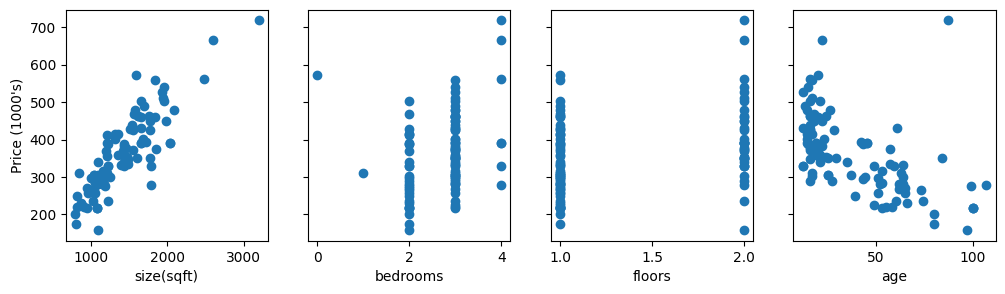

In [ ]:
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

Let's try running gradient descent with a first value for alpha.

In [ ]:
alpha = 9.9e-7
_, _, hist = run_gradient_descent(X_train, y_train, 10, alpha = 9.9e-7)

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 9.31055e+04  5.4e-01  9.9e-04  5.1e-04  1.2e-02  3.6e-04 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1 1.22207e+05 -8.0e-02 -1.6e-04 -9.3e-05 -3.2e-03 -4.4e-05  6.3e+05  1.2e+03  6.1e+02  1.6e+04  4.1e+02
        2 1.60562e+05  6.4e-01  1.1e-03  5.8e-04  1.3e-02  4.3e-04 -7.2e+05 -1.3e+03 -6.8e+02 -1.7e+04 -4.8e+02
        3 2.11110e+05 -1.9e-01 -3.7e-04 -2.1e-04 -7.0e-03 -1.0e-04  8.3e+05  1.5e+03  8.0e+02  2.0e+04  5.4e+02
        4 2.77730e+05  7.6e-01  1.4e-03  6.8e-04  1.5e-02  5.2e-04 -9.5e+05 -1.7e+03 -9.0e+02 -2.2e+04 -6.3e+02
        5 3.65531e+05 -3.3e-01 -6.4e-04 -3.6e-04 -1.2e-02 -1.9e-04  1.1e+06  2.0e+03  1.1e+03  2.7e+04  7.1e+02
        6 4.81246e+05  9.2e-01  1.6e-03  8.2e-04  1.7e-02  6.3e-04 -1.3e+06 -2.3e+03 -1.2e+03 -2.9e+04 -

But this rate of alpha might appear to high, resulting in divergence.

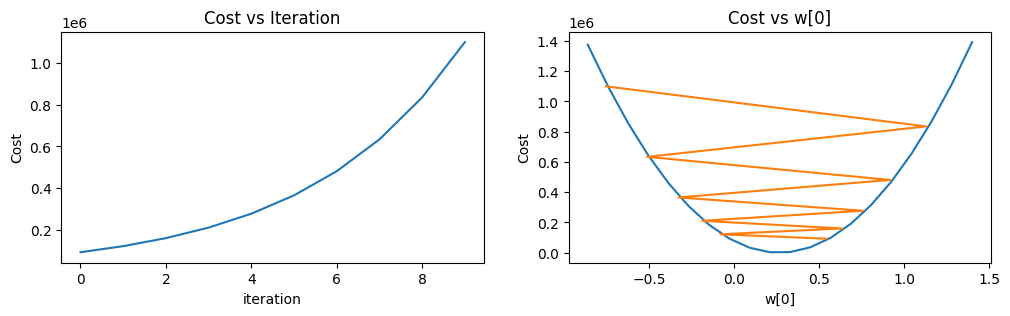

In [ ]:
plot_cost_i_w(X_train, y_train, hist)

Let's set alpha to a smaller value : 9e-7

In [ ]:
alpha = 9e-7
_, _, hist = run_gradient_descent(X_train, y_train, 10, alpha = 9.e-7)

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 6.46137e+04  4.9e-01  9.0e-04  4.6e-04  1.1e-02  3.3e-04 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1 5.87949e+04  2.3e-02  3.1e-05  7.5e-06 -6.2e-04  2.3e-05  5.2e+05  9.7e+02  5.1e+02  1.3e+04  3.4e+02
        2 5.35131e+04  4.7e-01  8.5e-04  4.3e-04  9.5e-03  3.2e-04 -5.0e+05 -9.1e+02 -4.7e+02 -1.1e+04 -3.3e+02
        3 4.87187e+04  4.5e-02  5.9e-05  1.3e-05 -1.3e-03  4.5e-05  4.7e+05  8.8e+02  4.6e+02  1.2e+04  3.1e+02
        4 4.43668e+04  4.5e-01  8.0e-04  3.9e-04  7.9e-03  3.1e-04 -4.5e+05 -8.2e+02 -4.2e+02 -1.0e+04 -3.0e+02
        5 4.04165e+04  6.4e-02  8.2e-05  1.7e-05 -2.0e-03  6.5e-05  4.3e+05  8.0e+02  4.2e+02  1.1e+04  2.8e+02
        6 3.68307e+04  4.3e-01  7.5e-04  3.6e-04  6.2e-03  3.1e-04 -4.1e+05 -7.5e+02 -3.8e+02 -9.2e+03 -

Cost decreases, which means alpha might not be too large.

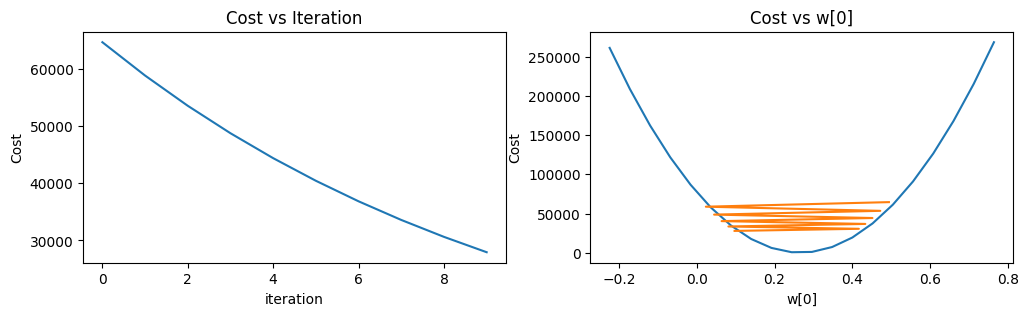

In [ ]:
plot_cost_i_w(X_train, y_train, hist)

For a even smaller value of alpha:

In [ ]:
alpha = 1e-7
_,_,hist = run_gradient_descent(X_train, y_train, 10, alpha = 1e-7)

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 4.41544e+04  5.5e-02  1.0e-04  5.2e-05  1.2e-03  3.6e-05 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1 2.76797e+04  9.8e-02  1.8e-04  9.2e-05  2.2e-03  6.5e-05 -4.3e+05 -7.8e+02 -4.0e+02 -9.6e+03 -2.8e+02
        2 1.75784e+04  1.3e-01  2.4e-04  1.2e-04  2.9e-03  8.7e-05 -3.4e+05 -6.1e+02 -3.1e+02 -7.4e+03 -2.2e+02
        3 1.13850e+04  1.6e-01  2.9e-04  1.5e-04  3.5e-03  1.0e-04 -2.6e+05 -4.8e+02 -2.4e+02 -5.6e+03 -1.8e+02
        4 7.58758e+03  1.8e-01  3.2e-04  1.7e-04  3.9e-03  1.2e-04 -2.1e+05 -3.7e+02 -1.9e+02 -4.3e+03 -1.4e+02
        5 5.25923e+03  1.9e-01  3.5e-04  1.8e-04  4.3e-03  1.3e-04 -1.6e+05 -2.9e+02 -1.5e+02 -3.2e+03 -1.1e+02
        6 3.83162e+03  2.1e-01  3.8e-04  1.9e-04  4.5e-03  1.4e-04 -1.3e+05 -2.3e+02 -1.1e+02 -2.4e+03 -

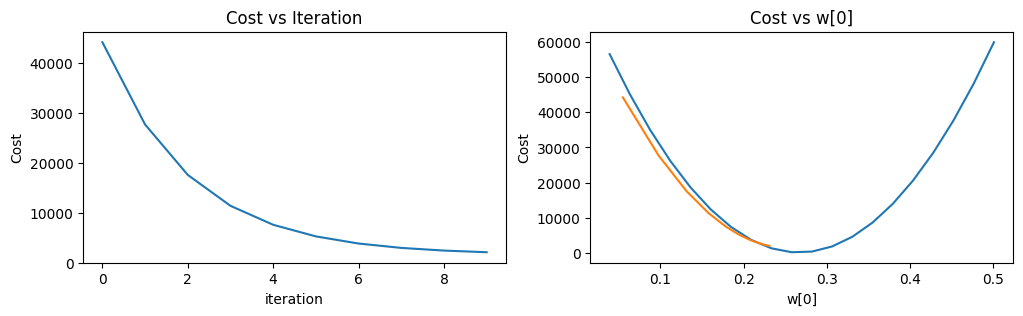

In [ ]:
plot_cost_i_w(X_train, y_train, hist)

Going back to feature scaling using Z-score normalization. 

In [ ]:
def zscore_normalize_features(X):
    """
    computes  X, zcore normalized by column
    
    Args:
      X (ndarray (m,n))     : input data, m examples, n features
      
    Returns:
      X_norm (ndarray (m,n)): input normalized by column
      mu (ndarray (n,))     : mean of each feature
      sigma (ndarray (n,))  : standard deviation of each feature
    """
    mu     = np.mean(X, axis=0)                 
    sigma  = np.std(X, axis=0)                  
    X_norm = (X - mu) / sigma      

    return (X_norm, mu, sigma)

Step by step transformation:

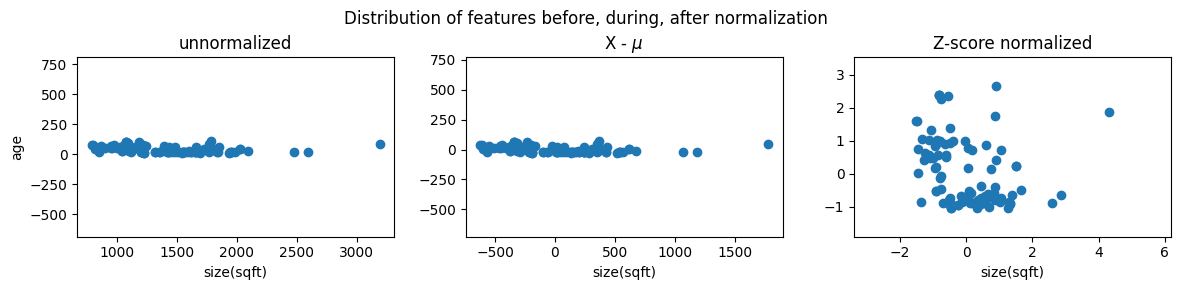

In [ ]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
X_mean =  X_train - mu
X_norm = (X_train - mu) / sigma

fig, ax = plt.subplots(1, 3, figsize=(12,3))
ax[0].scatter(X_train[:,0], X_train[:,3])
ax[0].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[3])
ax[0].set_title("unnormalized")
ax[0].axis('equal')

ax[1].scatter(X_mean[:,0], X_mean[:,3])
ax[1].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[1].set_title(r"X - $\mu$")
ax[1].axis('equal')

ax[2].scatter(X_norm[:,0], X_norm[:,3])
ax[2].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[2].set_title(r"Z-score normalized")
ax[2].axis('equal')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("Distribution of features before, during and after normalization")
plt.show()

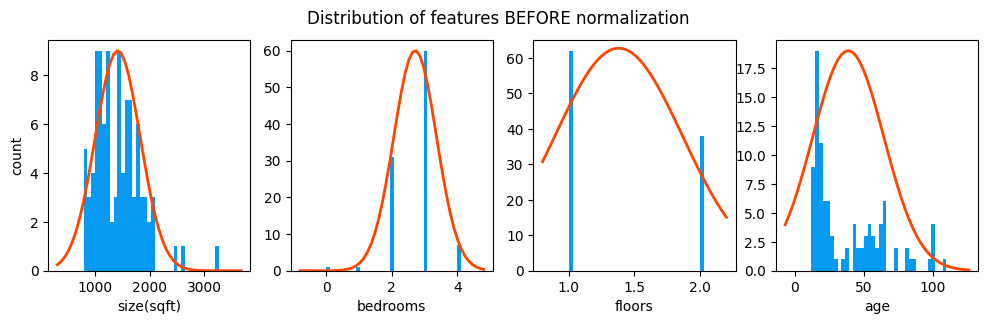

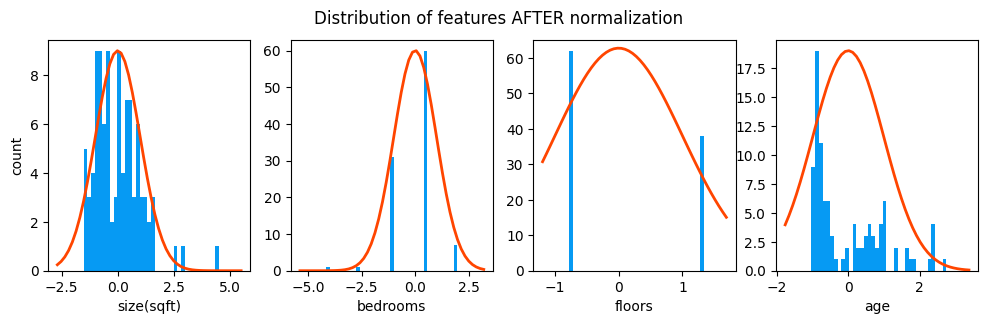

In [ ]:
fig,ax=plt.subplots(1, 4, figsize=(12, 3))
for i in range(len(ax)):
    norm_plot(ax[i],X_train[:,i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count");
fig.suptitle("Distribution of features BEFORE normalization")
plt.show()

fig,ax=plt.subplots(1,4,figsize=(12,3))
for i in range(len(ax)):
    norm_plot(ax[i],X_norm[:,i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count"); 
fig.suptitle("Distribution of features AFTER normalization")

plt.show()

In the graphs above, the range of the normalized data (x-axis) is centered around zero and roughly +/- 2 and is similar for each feature.

In [ ]:
w_norm, b_norm, hist = run_gradient_descent(X_norm, y_train, 1000, 1.0e-1, )

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 5.73264e+04  8.9e+00  3.0e+00  3.3e+00 -6.0e+00  3.6e+01 -8.9e+01 -3.0e+01 -3.3e+01  6.0e+01 -3.6e+02
      100 2.21728e+02  1.1e+02 -2.0e+01 -3.1e+01 -3.8e+01  3.6e+02 -9.4e-01  4.6e-01  5.4e-01 -1.8e-01 -9.6e-03
      200 2.19714e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.3e-02  1.6e-02  1.8e-02 -6.4e-03 -2.6e-07
      300 2.19711e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -1.1e-03  5.7e-04  6.3e-04 -2.2e-04 -6.9e-12
      400 2.19711e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.9e-05  2.0e-05  2.2e-05 -7.6e-06 -2.8e-13
      500 2.19711e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -1.3e-06  6.8e-07  7.5e-07 -2.6e-07 -2.2e-13
      600 2.19711e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -4.7e-08  2.4e-08  2.6e-08 -9.1e-09 -

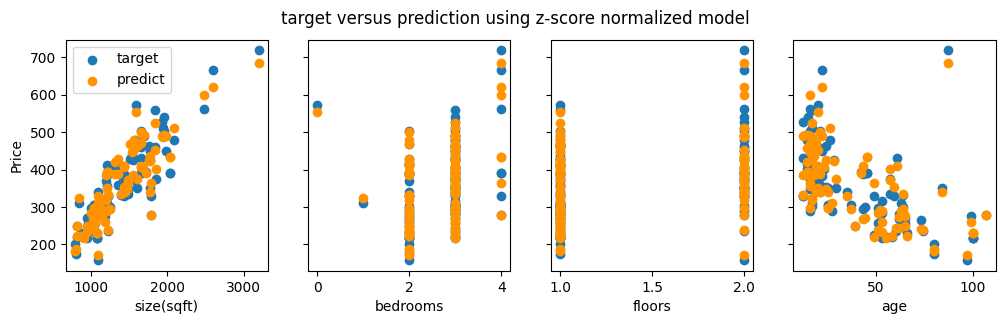

In [ ]:
# Predict target using normalized features
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_norm[i], w_norm) + b_norm

    # plot predictions and targets versus original features    
fig,ax=plt.subplots(1,4,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],yp,color=dlc["dlorange"], label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("Target vs Prediction using Z-score normalized model")
plt.show()

The point of generating the model is to use it to predict housing prices that are **not in the data set**. 

Let's predict the price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old. 

In [ ]:
# First, normalize out example.
x_house = np.array([1200, 3, 1, 40])
x_house_norm = (x_house - X_mu) / X_sigma
print(x_house_norm)
x_house_predict = np.dot(x_house_norm, w_norm) + b_norm
print(f" predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = ${x_house_predict*1000:0.0f}")

In [ ]:
plt_equal_scale(X_train, X_norm, y_train)



### Feature Engineering 

Choosing the right features is a critical step for the learning algorithm. Feature engineering is using intuition to design new features, by transforming or combining already existing features. 

For example, having two features length and width can give a third feature: the area (length x width).


### Polynomial Regression

Up to this point, linear regression data were represented on **fitting straight lines**. However, many real datasets are **not linear**, so a straight line does not always fit well.

**Polynomial regression** is a way to fit **curves** rather than lines by **creating new features** from the original one.


The idea is simple is to start with an original feature (e.g. $x$ = house size) and add new features like $x^$2 (square of size), $x^3$ (cube of size), etc. These new features allow the model to learn **non-linear relationships** while still using **linear regression** as the training algorithm.

The following is a linear regression function with engineered features: 
$$
f(x) = w_1 x + w_2 x^2 + w_3 x^3 + b
$$

For the housing price case, engineering features can take different ways:
- **Quadratic model** ($x^2$): might fit better, but eventually goes back down, which does not really make sense for housing prices.
- **Cubic model** ($x^3$): produces a curve that goes down first but eventually increases again, which matches the intuition that bigger homes are more expensive.

When creating polynomial features, their scales explode:

Another possibility is to use the square-root function, for the following benefits: 

- Increases at a decreasing rate
- Never flattens completely
- Never decreases

### Feature Engineering & Polynomial Regression Implementation

Let's try using a model to fit a non-linear curve, starting with $y = 1+x^2$

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from utils.lab_utils_multi import zscore_normalize_features, run_gradient_descent_feng
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

Iteration         0, Cost: 1.65756e+03
Iteration       100, Cost: 6.94549e+02
Iteration       200, Cost: 5.88475e+02
Iteration       300, Cost: 5.26414e+02
Iteration       400, Cost: 4.90103e+02
Iteration       500, Cost: 4.68858e+02
Iteration       600, Cost: 4.56428e+02
Iteration       700, Cost: 4.49155e+02
Iteration       800, Cost: 4.44900e+02
Iteration       900, Cost: 4.42411e+02
w,b found by gradient descent: w: [18.7], b: -52.0834


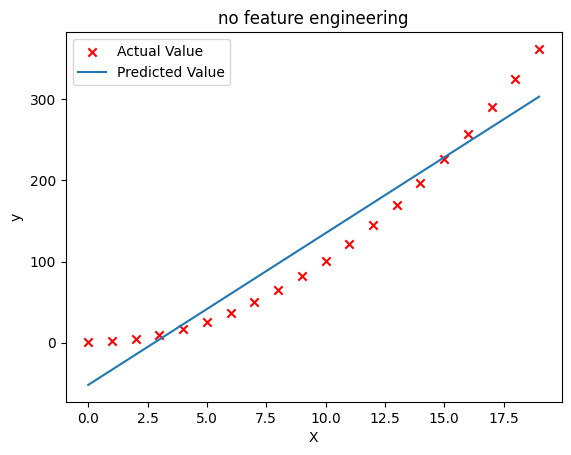

In [22]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2
X = x.reshape(-1, 1)

model_w,model_b = run_gradient_descent_feng(X,y,iterations=1000, alpha = 1e-2)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("no feature engineering")
plt.plot(x,X@model_w + model_b, label="Predicted Value");  plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.show()

Not a great fit. What is needed is something like $y= w_0x_0^2 + b$, or a **polynomial feature**.


In [23]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2

X = x**2      #<-- added engineered feature

Iteration         0, Cost: 7.32922e+03
Iteration      1000, Cost: 2.24844e-01
Iteration      2000, Cost: 2.22795e-01
Iteration      3000, Cost: 2.20764e-01
Iteration      4000, Cost: 2.18752e-01
Iteration      5000, Cost: 2.16758e-01
Iteration      6000, Cost: 2.14782e-01
Iteration      7000, Cost: 2.12824e-01
Iteration      8000, Cost: 2.10884e-01
Iteration      9000, Cost: 2.08962e-01
w,b found by gradient descent: w: [1.], b: 0.0490


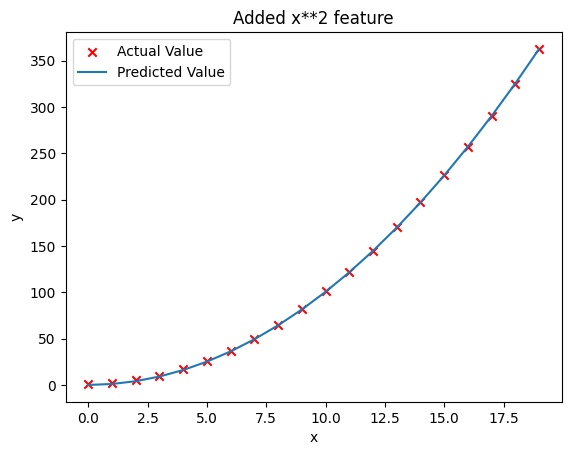

In [24]:
X = X.reshape(-1, 1)  #X should be a 2-D Matrix
model_w,model_b = run_gradient_descent_feng(X, y, iterations=10000, alpha = 1e-5)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Added x**2 feature")
plt.plot(x, np.dot(X,model_w) + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

Now it's perfect. But it may not be obvious which features are required. So one could add a variety of potential features to try and find the most useful.